In [59]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.signal import hilbert, welch, butter, filtfilt, spectrogram
from scipy.ndimage import uniform_filter1d
import segyio
import os, time

# ── Plotting defaults ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 12,
    'axes.labelsize'  : 10,
    'xtick.labelsize' : 8,
    'ytick.labelsize' : 8,
    'font.family'     : 'DejaVu Sans',
})
CMAP_SEIS  = 'seismic'
CMAP_AMP   = 'plasma'
CMAP_PHASE = 'hsv'
CMAP_FREQ  = 'jet'



In [2]:
def load_seismic_data(filepath):
    with segyio.open(filepath, "r", ignore_geometry=True) as f:
        f.mmap()

        # Try to detect geometry
        has_geometry = (
            f.ilines is not None and
            f.xlines is not None and
            f.offsets is not None
        )

        if has_geometry:
            print("✅ Structured 3D detected")
            data = segyio.tools.cube(f)

            # Handle 3D or 4D
            if data.ndim == 4:  # prestack
                data = data[:, :, 0, :]
            elif data.ndim == 3:
                data = data[0, :, :]  # take one inline

        else:
            print("In this data we have no geometry → loading as 2D traces")
            n_traces = f.tracecount
            n_samples = len(f.samples)

            data = np.zeros((n_traces, n_samples), dtype=np.float32)

            for i in range(n_traces):
                data[i, :] = f.trace[i]

        return data.T  # (samples, traces)

filepath = "/home/ashraf/Downloads/ST8511r92.segy"  

seismic = load_seismic_data(filepath)

print("Shape:", seismic.shape)
print("Shape:", seismic.shape)
print("Samples:", seismic.shape[0])
print("Traces:", seismic.shape[1])


In this data we have no geometry → loading as 2D traces
Shape: (227, 112875)
Shape: (227, 112875)
Samples: 227
Traces: 112875


In [16]:
import segyio
t0=time.time()
with segyio.open("/home/ashraf/Downloads/ST8511r92.segy", "r", ignore_geometry=True) as f:
    print("Traces:", f.tracecount)
    print("Samples per trace:", len(f.samples))
    print("Inline:", f.ilines)
    print("Crossline:", f.xlines)
    print("Offsets:", f.offsets)

    # DT
    dt_ms=segyio.tools.dt(f)/1000.0     # µs → ms
    print("The dt of the seismic data is:",dt_ms)

    print("Sample size of the data:",f.samples.size)
    data=segyio.tools.collect(f.trace[:]) # (n_traces, n_samples)
    data=data.T     # → (n_samples, n_traces)

    print(data)

Traces: 112875
Samples per trace: 227
Inline: None
Crossline: None
Offsets: None
The dt of the seismic data is: 4.003
Sample size of the data: 227
[[ 3938.5374    2510.3716    -167.43929  ... -1595.6051   -1238.5636
  -1595.6051  ]
 [ 2153.33      6259.3066    4652.62     ...  1617.768    -1774.1259
  -4630.4575  ]
 [   11.081434  8580.076     9294.159    ...  3581.4958   -1060.043
  -5701.582   ]
 ...
 [ 1617.768     1439.2472    1082.2058   ... -2845.2502   -2309.688
     11.081434]
 [ 2153.33       725.16437   -345.96002  ... -2309.688    -2131.1672
    189.60216 ]
 [ 1260.7266    -881.5222   -2131.1672   ... -1060.043    -1238.5636
   -345.96002 ]]


### Visualisation of seismic data

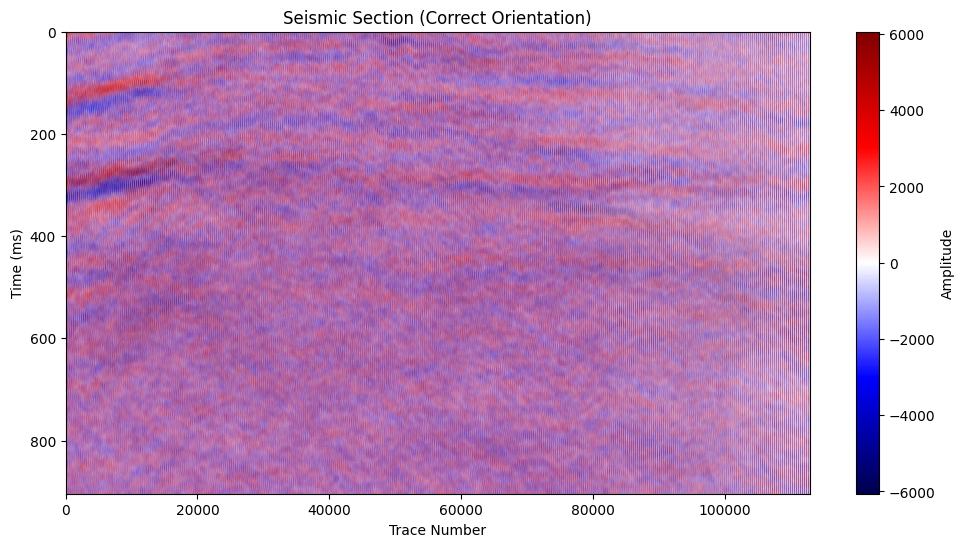

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_seismic(seismic, dt=0.004, clip=98):
    """
    seismic: (samples, traces)
    dt: sampling interval in seconds (default 4 ms)
    """
    
    n_samples, n_traces = seismic.shape
    
    # Time axis (in ms)
    time = np.arange(n_samples) * dt * 1000
    
    # Amplitude clipping (VERY IMPORTANT)
    vmax = np.percentile(np.abs(seismic), clip)
    
    plt.figure(figsize=(12, 6))
    
    plt.imshow(
        seismic,
        cmap='seismic',   # industry standard
        aspect='auto',
        vmin=-vmax,
        vmax=vmax,
        extent=[0, n_traces, time[-1], time[0]]  # correct time axis
    )
    
    plt.xlabel("Trace Number")
    plt.ylabel("Time (ms)")
    plt.title("Seismic Section (Correct Orientation)")
    
    plt.colorbar(label="Amplitude")
    
    plt.show()
plot_seismic(seismic)

In [20]:
import segyio
t0=time.time()
with segyio.open("/home/ashraf/Downloads/ST8511r92.segy", "r", ignore_geometry=True) as f:
    N_SAMPLES=f.samples.size
    N_TRACES=f.tracecount
    print("Traces:", N_TRACES)
    print("Samples per trace:", N_SAMPLES)
    print("Inline:", f.ilines)
    print("Crossline:", f.xlines)
    print("Offsets:", f.offsets)

    # DT
    dt_ms=segyio.tools.dt(f)/1000.0     # µs → ms
    print("The dt of the seismic data is:",dt_ms)

    print("Sample size of the data:",f.samples.size)
    data=segyio.tools.collect(f.trace[:]) # (n_traces, n_samples)
    data=data.T     # → (n_samples, n_traces)

    print(data)



Traces: 112875
Samples per trace: 227
Inline: None
Crossline: None
Offsets: None
The dt of the seismic data is: 4.003
Sample size of the data: 227
[[ 3938.5374    2510.3716    -167.43929  ... -1595.6051   -1238.5636
  -1595.6051  ]
 [ 2153.33      6259.3066    4652.62     ...  1617.768    -1774.1259
  -4630.4575  ]
 [   11.081434  8580.076     9294.159    ...  3581.4958   -1060.043
  -5701.582   ]
 ...
 [ 1617.768     1439.2472    1082.2058   ... -2845.2502   -2309.688
     11.081434]
 [ 2153.33       725.16437   -345.96002  ... -2309.688    -2131.1672
    189.60216 ]
 [ 1260.7266    -881.5222   -2131.1672   ... -1060.043    -1238.5636
   -345.96002 ]]


In [30]:
# Derived parameter
time_axis=np.arange(N_SAMPLES)
trace_axis=np.arange(N_TRACES)
# print(time_axis)
# Sampling frequency
fs=1000/dt_ms
print("sampling frequency is (in HZ):",fs )
nyquist_frequency=fs/2.0

print("Nyquist frequency is (in HZ):",nyquist_frequency)

sampling frequency is (in HZ): 249.81264051961028
Nyquist frequency is (in HZ): 124.90632025980514


In [28]:
print(f"   Samples   : {N_SAMPLES}")
print(f"   Traces    : {N_TRACES}")
print(f"   dt        : {dt_ms} ms  →  fs = {fs:.0f} Hz  |  Nyquist = {nyquist_frequency:.0f} Hz")
print(f"   Record length : {time_axis[-1]:.1f} ms")


   Samples   : 227
   Traces    : 112875
   dt        : 4.003 ms  →  fs = 250 Hz  |  Nyquist = 125 Hz
   Record length : 226.0 ms


## 3 · Data Quality Checks & Statistics
Before computing any attribute we must understand the **amplitude distribution**.

- **Clipping** → histogram with sharp cutoffs → normalise or clip before attributes  
- **Outlier traces** → dead traces (all zeros) or noisy traces  
- **Dynamic range** → ratio of max to RMS amplitude; > 60 dB is typical for quality data

$$
\mathrm{RMS}_i = \sqrt{\frac{1}{N} \sum_{t=1}^{N} x_{t,i}^2}
$$

$$
\begin{aligned}
x_{t,i} &:\ \text{Amplitude of the signal at time sample } t \text{ for trace } i \\
N       &:\ \text{Total number of time samples in one trace} \\
t       &:\ \text{Time sample index } (t = 1,2,\dots,N) \\
i       &:\ \text{Trace index (i-th seismic trace)} \\
\mathrm{RMS}_i &:\ \text{Root Mean Square amplitude of trace } i
\end{aligned}
$$

$$
\mathrm{Dynamic\ Range} = 20 \log_{10} \left( \frac{g_{\max}}{g_{\mathrm{RMS}} + 10^{-10}} \right)
$$

$$
\begin{aligned}
g_{\max} &:\ \text{Maximum amplitude in the dataset} \\
g_{\mathrm{RMS}} &:\ \text{Root Mean Square amplitude (global or per-trace)} \\
10^{-10} &:\ \text{Small constant to avoid division by zero} \\
\mathrm{Dynamic\ Range} &:\ \text{Amplitude ratio expressed in decibels (dB)}
\end{aligned}
$$

In [61]:
# RMS PER TRACE
rms_per_trace=np.sqrt(np.mean(data**2,axis=0))
print("RMS per trace is :",rms_per_trace)


# ── Global statistics ─────────────────────────────────────────────────────────
g_max,g_min=data.max(),data.mean()
g_mean=data.mean()
g_std=data.std()
g_rms=np.sqrt(np.mean(pow(data,2)))

dynamic_range=20*np.log10(g_max/(g_rms+1e-10))

dead_traces=np.sum(rms_per_trace==0)

print("="*60)
print("   GLOBAL AMPLITUDE STATISTICS OF THE SEISMIC DATA ")
print("="*60)

print(f"Min           :{g_min}")
print(f"Max           :{g_max}")
print(f"Mean          :{g_mean}")
print(f"Std dev       :{g_std}")
print(f"RMS           :{g_rms}")
print(f"Dynamic Range :{dynamic_range}")
print(f"Dead traces   :{dead_traces}")




RMS per trace is : [2713.5808 2719.4683 2718.9675 ... 2399.4233 2283.5789 2590.8801]
   GLOBAL AMPLITUDE STATISTICS OF THE SEISMIC DATA 
Min           :-3.6413514614105225
Max           :14114.21875
Mean          :-3.6413514614105225
Std dev       :2558.947021484375
RMS           :2558.949951171875
Dynamic Range :14.831901550292969
Dead traces   :0


### Amplitude histogram + per-trace RMS ──────────────────────────────


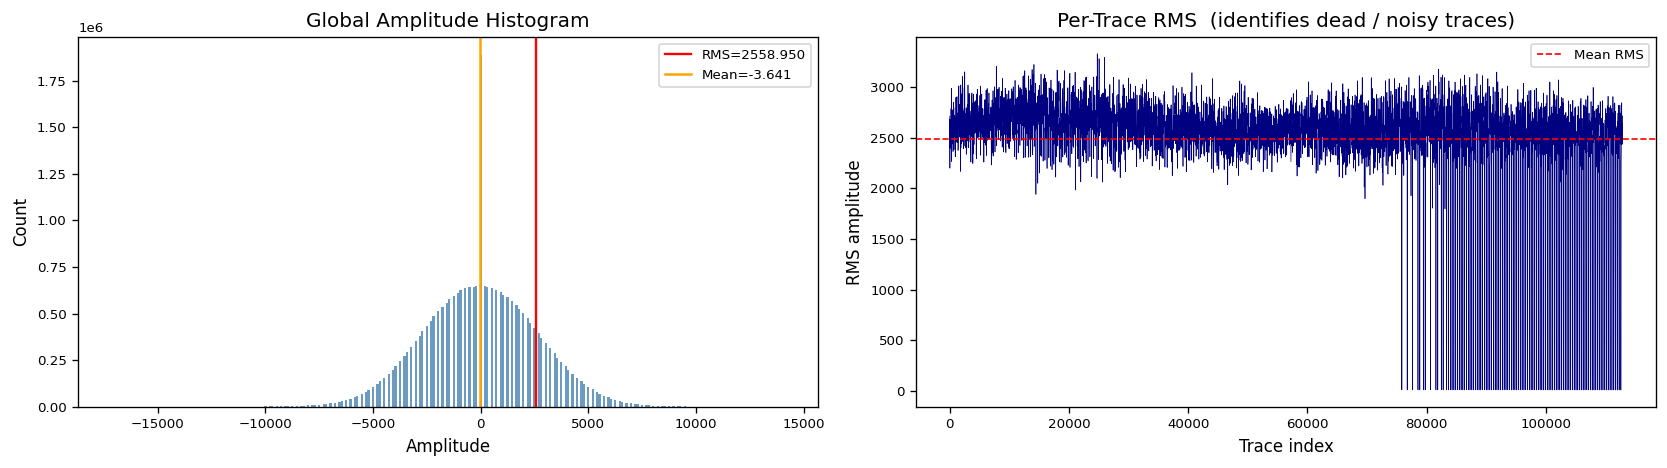

In [63]:
fig,axes=plt.subplots(1,2,figsize=(14,4))

axes[0].hist(data.ravel(),bins=300,color="steelblue",edgecolor="none",alpha=0.80)
axes[0].set_xlabel("Amplitude")
axes[0].set_ylabel("Count")
axes[0].set_title("Global Amplitude Histogram")
axes[0].axvline(g_rms,color="red", lw=1.4, label=f"RMS={g_rms:0.3f}")
axes[0].axvline(g_mean,color="orange",lw=1.5,label=f"Mean={g_mean:0.3f}")
axes[0].legend(fontsize=8)


step = max(1, N_TRACES // 5000)          # decimate for speed
axes[1].plot(trace_axis[::step], rms_per_trace[::step], lw=0.4, color='navy')
axes[1].set_xlabel("Trace index")
axes[1].set_ylabel("RMS amplitude")
axes[1].set_title("Per-Trace RMS  (identifies dead / noisy traces)")
axes[1].axhline(rms_per_trace.mean(), color='red', lw=1, ls='--', label='Mean RMS')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


##  Raw Trace Visualisation
We plot a **wiggle display** of a handful of individual traces.  
This is the most direct look at the seismic waveform — each trace is a time-series
of reflected acoustic energy.

Key waveform features to observe:
- **Zero crossings** → reflector boundaries
- **Peak polarity** → acoustic impedance contrast direction
- **Wavelet shape** → bandwidth, phase, ringing


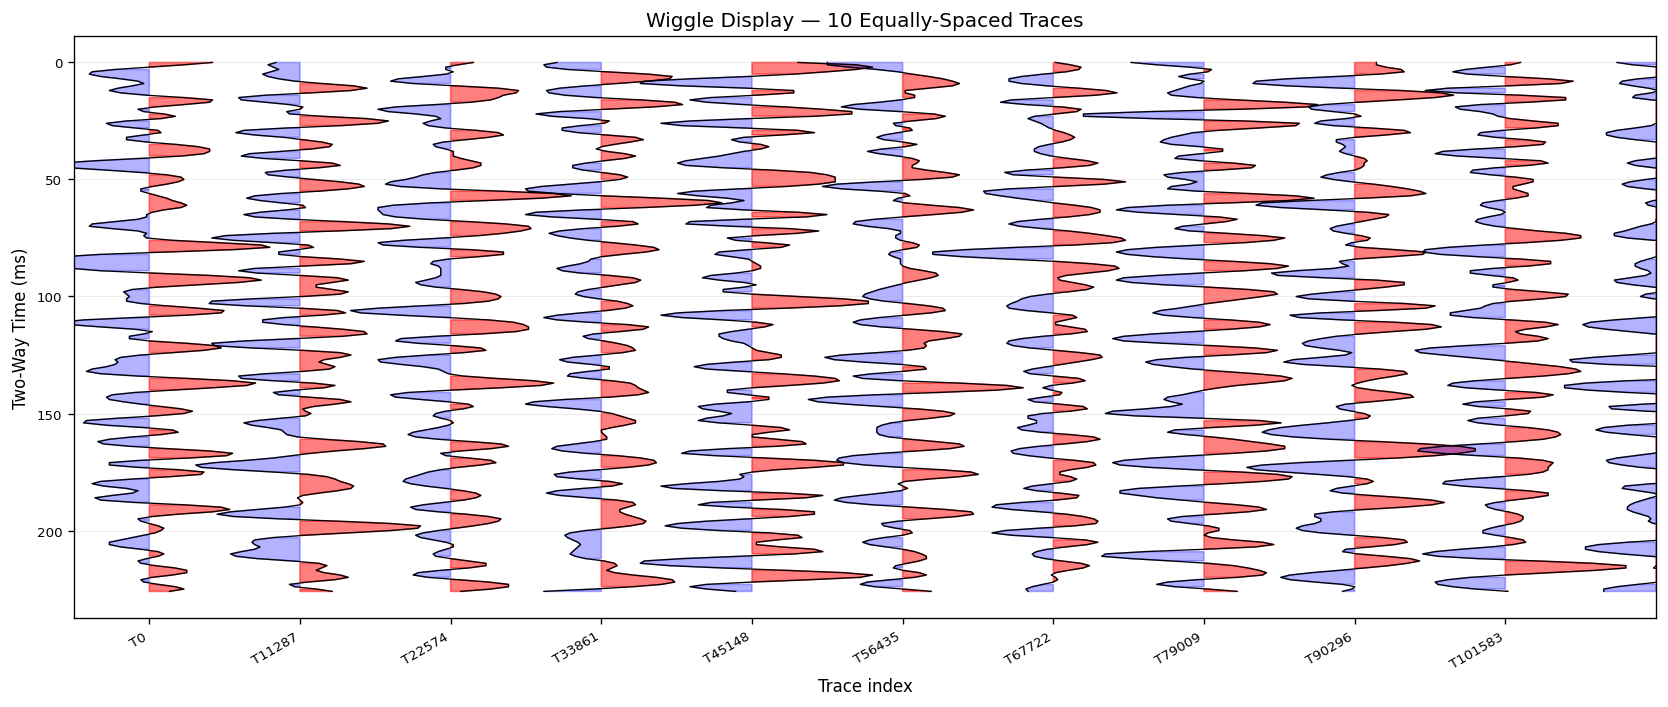

In [69]:
N_WIGGLE = 10  # how many traces to show
step_w   = N_TRACES // N_WIGGLE

fig, ax = plt.subplots(figsize=(14, 6))
for k, ti in enumerate(range(0, N_TRACES, step_w)):
    tr  = data[:, ti]
    tr_n = tr / (np.abs(tr).max() + 1e-10)       # normalise to [-1, 1]
    ax.plot(tr_n * 0.8 + k, time_axis, lw=0.8, color='black')
    # shade positive lobes
    ax.fill_betweenx(time_axis, k, tr_n * 0.8 + k,
                     where=(tr_n > 0), color='red',  alpha=0.5)
    ax.fill_betweenx(time_axis, k, tr_n * 0.8 + k,
                     where=(tr_n < 0), color='blue', alpha=0.3)

ax.set_xlim(-0.5, N_WIGGLE)
ax.set_xticks(range(N_WIGGLE))
ax.set_xticklabels([f"T{i*step_w}" for i in range(N_WIGGLE)], rotation=30, ha='right')
ax.invert_yaxis()
ax.set_xlabel("Trace index")
ax.set_ylabel("Two-Way Time (ms)")
ax.set_title(f"Wiggle Display — {N_WIGGLE} Equally-Spaced Traces")
ax.grid(axis='y', lw=0.3, alpha=0.5)
plt.tight_layout(); plt.show()